In [74]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter

#https://www.kaggle.com/datasets/davidcariboo/player-scores
df = pd.read_csv("../players.csv")

df = df[df['foot'].notna() & \
        df['position'].notna() & \
        (df['position'] != 'Missing') & \
        df['height_in_cm'].notna() & \
        df['market_value_in_eur'].notna()].copy()

df['foot_encoded'] = df['foot'].map({'left': 0, 'right': 1})
df['position_encoded'] = df['position'].map({'Goalkeeper': 0, 'Defender': 1, 'Attack': 2, 'Midfield': 3})
position_dummies = pd.get_dummies(df['position'], prefix='position', drop_first=True)

data = pd.concat(
    [
        df[['height_in_cm', 'market_value_in_eur', 'foot_encoded']].reset_index(drop=True),
        position_dummies.reset_index(drop=True),
    ],
    axis=1,
)
data['high_value'] = (data['market_value_in_eur'] > data['market_value_in_eur'].median()).astype(int)
# log transform market value
data['market_value_in_eur'] = np.log1p(data['market_value_in_eur'])

# ensure all features are numeric and filled
feature_columns = ['height_in_cm', 'foot_encoded'] + list(position_dummies.columns)
data[feature_columns] = data[feature_columns].fillna(0)

# remove outliers using IQR
for col in ['height_in_cm', 'market_value_in_eur']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

X = data[feature_columns].to_numpy(dtype=float)
y = data['high_value'].values

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Distribution in train:", Counter(y_train))
print("Distribution in test:", Counter(y_test))

majority = max(Counter(y_train).values())
minority = min(Counter(y_train).values())

if minority / majority < 0.3:
    smote = SMOTE()
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("After smote:", Counter(y_train))

# z-score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"Training set size: {X_train_poly.shape[0]}")
print(f"Test set size: {X_test_poly.shape[0]}")

Distribution in train: Counter({np.int64(0): 11496, np.int64(1): 10636})
Distribution in test: Counter({np.int64(0): 2923, np.int64(1): 2611})
Training set size: 22132
Test set size: 5534


cluster sizes: [7406 9077 6139 5044]


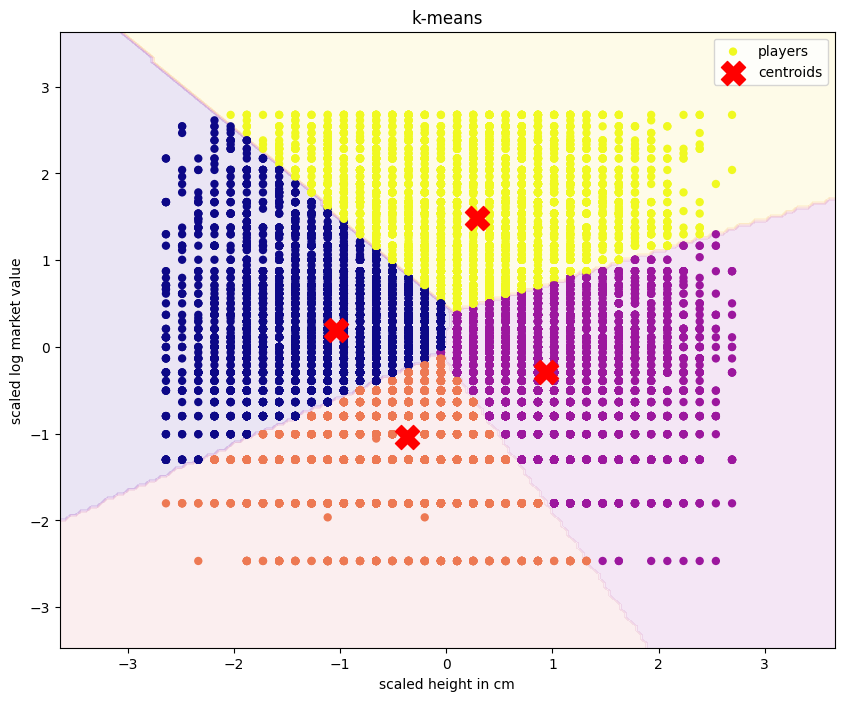

In [75]:
class KMeansClustering:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        
    def fit_predict(self, X):
        random_idx = np.random.choice(X.shape[0], self.k, replace=False)
        self.centroids = X[random_idx]
        
        for i in range(self.max_iters):
            distances = self.__compute_distances(X)
            labels = np.argmin(distances, axis=1)
            
            new_centroids = np.array([
                X[labels == j].mean(axis=0) if len(X[labels == j]) > 0 else self.centroids[j] 
                for j in range(self.k)
            ])
            
            if np.all(np.abs(new_centroids - self.centroids) < self.tol):
                break
                
            self.centroids = new_centroids
            
        return labels

    def predict(self, X):
        distances = self.__compute_distances(X)
        return np.argmin(distances, axis=1)
        
    def __compute_distances(self, X):
        distances = np.zeros((X.shape[0], self.k))
        for i, c in enumerate(self.centroids):
            distances[:, i] = np.linalg.norm(X - c, axis=1)
        return distances

features = data[['height_in_cm', 'market_value_in_eur']].copy()
X = StandardScaler().fit_transform(features.values)

# 4 groups short/low-val, tall/low-val, short/high-val, tall/high-val
kmeans = KMeansClustering(k=4, max_iters=100)
cluster_labels = kmeans.fit_predict(X)

print(f"cluster sizes: {np.bincount(cluster_labels)}")

h = 0.05
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.1, cmap='plasma')

plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='plasma', edgecolors='none', label='players')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', marker='X', s=300, label='centroids')
plt.title('k-means')
plt.xlabel('scaled height in cm')
plt.ylabel('scaled log market value')
plt.legend()
plt.show()

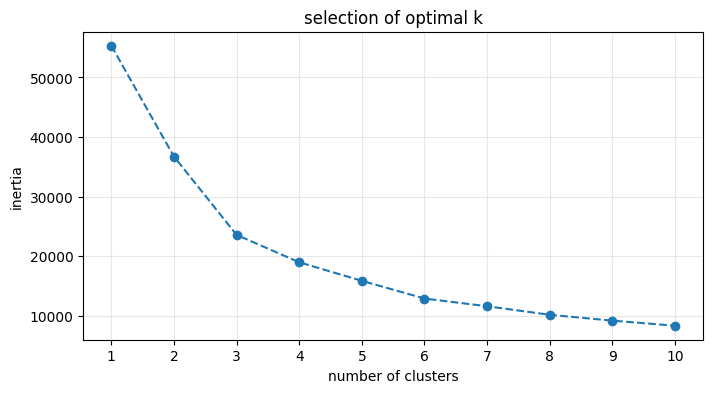

k-means k=4
Set 1 cluster distribution: {np.int32(0): 5557, np.int32(2): 8899, np.int32(1): 9386, np.int32(3): 3824}
Set 2 cluster distribution: {np.int32(1): 7656, np.int32(3): 2938, np.int32(2): 8046, np.int32(0): 9026}
dbscan
Set 1 cluster distribution: {np.int64(0): 26455, np.int64(1): 1004, np.int64(2): 183, np.int64(-1): 24}
Set 2 cluster distribution: {np.int64(0): 5527, np.int64(1): 466, np.int64(2): 2472, np.int64(3): 2172, np.int64(4): 5874, np.int64(5): 3416, np.int64(6): 5610, np.int64(7): 2129}


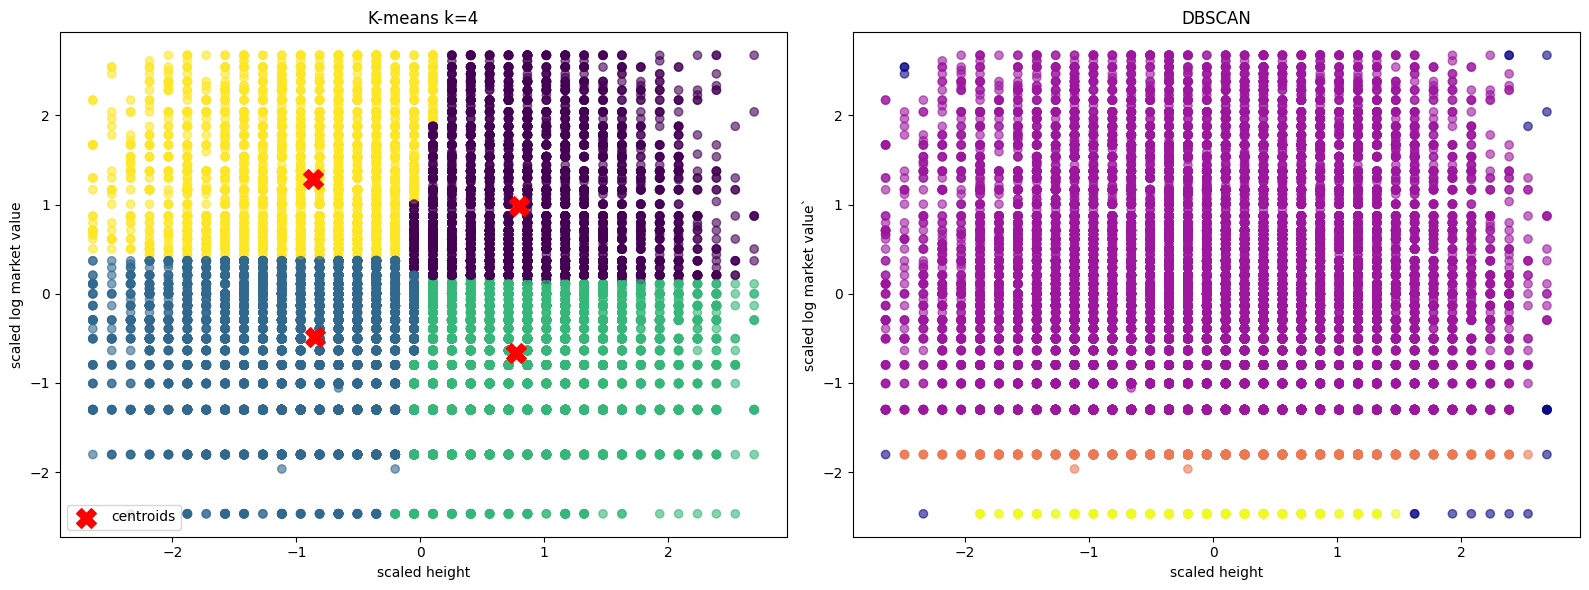

In [76]:
from sklearn.cluster import KMeans, DBSCAN
from collections import Counter

# different feature sets
features_set1 = data[['height_in_cm', 'market_value_in_eur']].copy()
X_set1 = StandardScaler().fit_transform(features_set1)

X_set2 = StandardScaler().fit_transform(data[feature_columns])

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, n_init='auto')
    kmeans_temp.fit(X_set1)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', linestyle='--')
plt.title('selection of optimal k')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

optimal_k = 4 


kmeans_model1 = KMeans(n_clusters=optimal_k, n_init='auto')
labels_k1 = kmeans_model1.fit_predict(X_set1)

kmeans_model2 = KMeans(n_clusters=optimal_k, n_init='auto')
labels_k2 = kmeans_model2.fit_predict(X_set2)

dbscan_model1 = DBSCAN(eps=0.3, min_samples=10)
labels_d1 = dbscan_model1.fit_predict(X_set1)

dbscan_model2 = DBSCAN(eps=1.5, min_samples=5)
labels_d2 = dbscan_model2.fit_predict(X_set2)

print(f"k-means k={optimal_k}")
print("Set 1 cluster distribution:", dict(Counter(labels_k1)))
print("Set 2 cluster distribution:", dict(Counter(labels_k2)))

print(f"dbscan")
print("Set 1 cluster distribution:", dict(Counter(labels_d1)))
print("Set 2 cluster distribution:", dict(Counter(labels_d2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(X_set1[:, 0], X_set1[:, 1], c=labels_k1, cmap='viridis', alpha=0.6)
ax1.scatter(kmeans_model1.cluster_centers_[:, 0], kmeans_model1.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, label='centroids')
ax1.set_title(f'K-means k={optimal_k}')
ax1.set_xlabel('scaled height')
ax1.set_ylabel('scaled log market value')
ax1.legend()

scatter = ax2.scatter(X_set1[:, 0], X_set1[:, 1], c=labels_d1, cmap='plasma', alpha=0.6)
ax2.set_title('DBSCAN')
ax2.set_xlabel('scaled height')
ax2.set_ylabel('scaled log market value`')

plt.tight_layout()
plt.show()

silhouette score, set 2 k=4), 0.4520


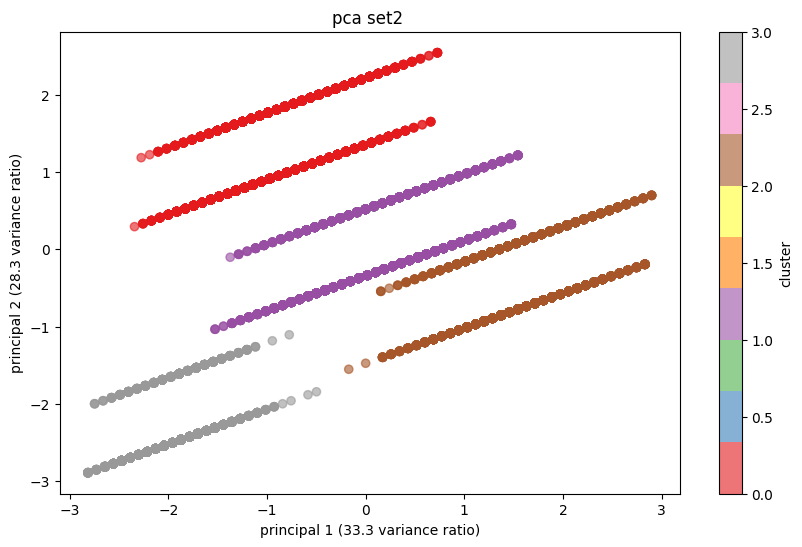

cluster 1: 7656 players
cluster 3: 2938 players
cluster 2: 8046 players
cluster 0: 9026 players


,height_in_cm,foot_encoded,position_Defender,position_Goalkeeper,position_Midfield
0,0.20,-0.18,1.44,-0.34,-0.64
1,-0.22,0.04,-0.70,-0.34,-0.64
2,-0.42,0.06,-0.70,-0.34,1.56
3,1.11,0.30,-0.70,2.90,-0.64


cluster 0:
high traits: position_Defender (+1.44)
low traits:  position_Goalkeeper (-0.34), position_Midfield (-0.64)
cluster 1:
low traits:  position_Goalkeeper (-0.34), position_Midfield (-0.64), position_Defender (-0.70)
cluster 2:
high traits: position_Midfield (+1.56)
low traits:  position_Goalkeeper (-0.34), height_in_cm (-0.42), position_Defender (-0.70)
cluster 3:
high traits: position_Goalkeeper (+2.90), height_in_cm (+1.11), foot_encoded (+0.30)
low traits:  position_Midfield (-0.64), position_Defender (-0.70)


In [77]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X_eval = X_set2
labels_eval = labels_k2
model_eval = kmeans_model2

sil_score = silhouette_score(X_eval, labels_eval)
print(f"silhouette score, set 2 k={optimal_k}), {sil_score:.4f}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_eval)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_eval, cmap='Set1', alpha=0.6)
plt.title('pca set2 ')
plt.xlabel(f'principal 1 ({pca.explained_variance_ratio_[0]*100:.1f} variance ratio)')
plt.ylabel(f'principal 2 ({pca.explained_variance_ratio_[1]*100:.1f} variance ratio)')
plt.colorbar(scatter, label='cluster')
plt.show()

cluster_sizes = dict(Counter(labels_eval))
for cluster_id, size in cluster_sizes.items():
    print(f"cluster {cluster_id}: {size} players")

centroids_df = pd.DataFrame(model_eval.cluster_centers_, columns=feature_columns)
display(centroids_df.round(2))

for i in range(optimal_k):
    print(f"cluster {i}:")
    traits = centroids_df.iloc[i].sort_values(ascending=False)
    high_traits = [f"{k} (+{v:.2f})" for k,v in traits.items() if v > 0.3]
    low_traits = [f"{k} ({v:.2f})" for k,v in traits.items() if v < -0.3]
    
    if high_traits:
        print(f"high traits: {', '.join(high_traits)}")
    if low_traits:
        print(f"low traits:  {', '.join(low_traits)}")
    
    if not high_traits and not low_traits:
        print("average players")

1. Physical traits and market value scale with no gaps.
2. Player position forces the algorithm to split players based on function.
3. Elite market value naturally clusters high-tier players together regardless of their physical size difference.
4. Being exceptionally tall correlates strongly with Goalkeeper and Defender cluster groupings.
5. Extreme outlier points show generational talents, whose value is much higher than the average.